In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import re
import matplotlib 
import matplotlib as mpl
from pathlib import Path

In [3]:
driver = "elav"
responder = "eOPN3"
illum_duration = 5 
time = str(illum_duration)+ "s"

genotypefilename = driver + " x " + responder  + "_" + time
drivercontrol_name = "w1118 x " + driver + "_" + time
respondercontrol_name = "w1118 x " + responder + "_" + time

homecomp = "D:"
base_path = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\2. Processed\\"  
specifiedpath = homecomp + base_path

# Analysis parameters
bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
 # illumination duration (seconds)
maxtime = 3600
intendedtime = 600

exp_path = specifiedpath + genotypefilename
drivercontrol_path = specifiedpath + drivercontrol_name
respondercontrol_path = specifiedpath + respondercontrol_name

#change here
fileofinterest = exp_path
fileofinterestname = genotypefilename

In [ ]:
exp_combined_df = pd.read_csv(fileofinterest + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
intendedtimeexp = exp_combined_df.iloc[0:(intendedtime*2),:] #0.5 per fps so *2\

minutegraphs = intendedtimeexp.reset_index(drop=False)
time_cols = [col for col in minutegraphs.columns if "Time (s)" in col]
for col in time_cols:
    minutegraphs[col.replace("Time (s)", "Time(min)")] = minutegraphs[col] / 60
minutegraphs = minutegraphs.drop(columns=time_cols)
minutegraphs = minutegraphs.set_index("Time(min)") 

metric = ['ActivityLevel', "Speed"]

## Shorter time (seconds)

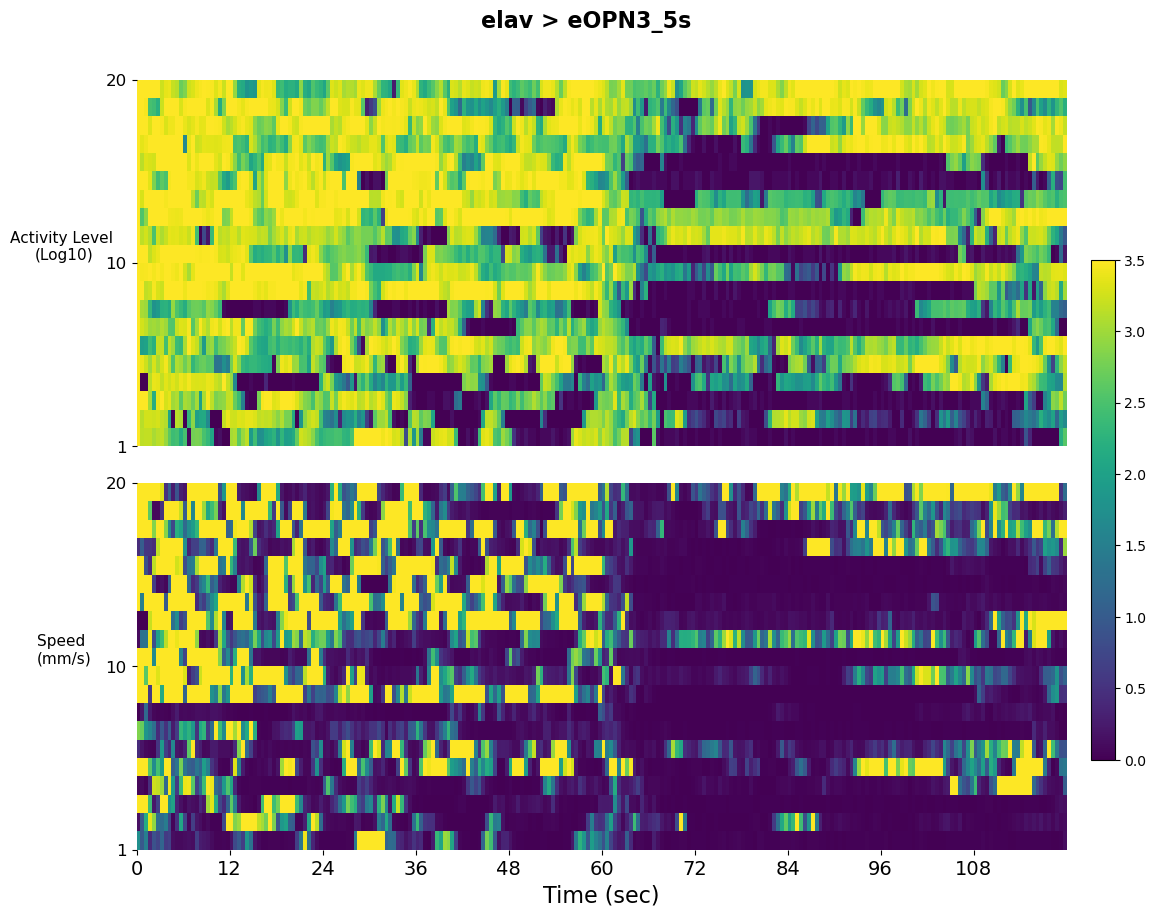

In [69]:
specifictime = 120  #100s
specifictime_df = intendedtimeexp.iloc[0:(specifictime*2),:]

if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"

activitylevel_data = specifictime_df.filter(regex="^ActivityLevel").T.reset_index(drop=True)
speed_data = specifictime_df.filter(regex="^Speed").T.reset_index(drop=True)

num_flies = activitylevel_data.shape[0]


fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
plt.subplots_adjust(hspace=0.1) 

# acitivtylevel
hm1 = sns.heatmap(activitylevel_data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, vmin=0, vmax=3.5, ax=axes[0])
quadmesh1 = axes[0].collections[0]
quadmesh1.set_rasterized(True)
quadmesh1.set_edgecolor('face')
quadmesh1.set_linewidth(0)

axes[0].set_ylabel("Activity Level \n(Log10)", rotation=0, labelpad=30, fontsize=11)

axes[0].set_yticks([0, num_flies//2, num_flies])
ticklabels = [num_flies, (num_flies+1)//2, 1]
axes[0].set_yticklabels(ticklabels, fontsize=12)
axes[0].tick_params(axis='x', bottom=False)                                                                                                   
axes[0].set_xlabel('')

# speed
hm2 = sns.heatmap(speed_data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, vmin=0, vmax=3.5, ax=axes[1])
quadmesh2 = axes[1].collections[0]
quadmesh2.set_rasterized(True)
quadmesh2.set_edgecolor('face')
quadmesh2.set_linewidth(0)
axes[1].set_ylabel("Speed \n(mm/s)", rotation=0, labelpad=30, fontsize=11)
axes[1].set_yticks([0, num_flies])
axes[1].set_yticklabels([num_flies, 1], fontsize=12)


tick_times = list(range(0, int(specifictime), int(specifictime/10)))
tick_positions = [list(speed_data.columns).index(float(t)) for t in tick_times if float(t) in speed_data.columns]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_times, rotation=0, fontsize=14)
axes[1].set_xlabel("Time (sec)", fontsize=16)
axes[1].set_yticks([0, num_flies//2, num_flies])
axes[1].set_yticklabels(ticklabels, fontsize=12)

cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.5])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=3.5))
fig.colorbar(sm, cax=cbar_ax)

fig.suptitle(fileofinterestname.replace("x", ">"), weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')
axes[0].patch.set_facecolor('white')
axes[1].patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\"
#             + "Combined_heatmap_" + fileofinterestname + "_" +str(illum_duration) + "s.svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)

## Longer heatmap (minutes)

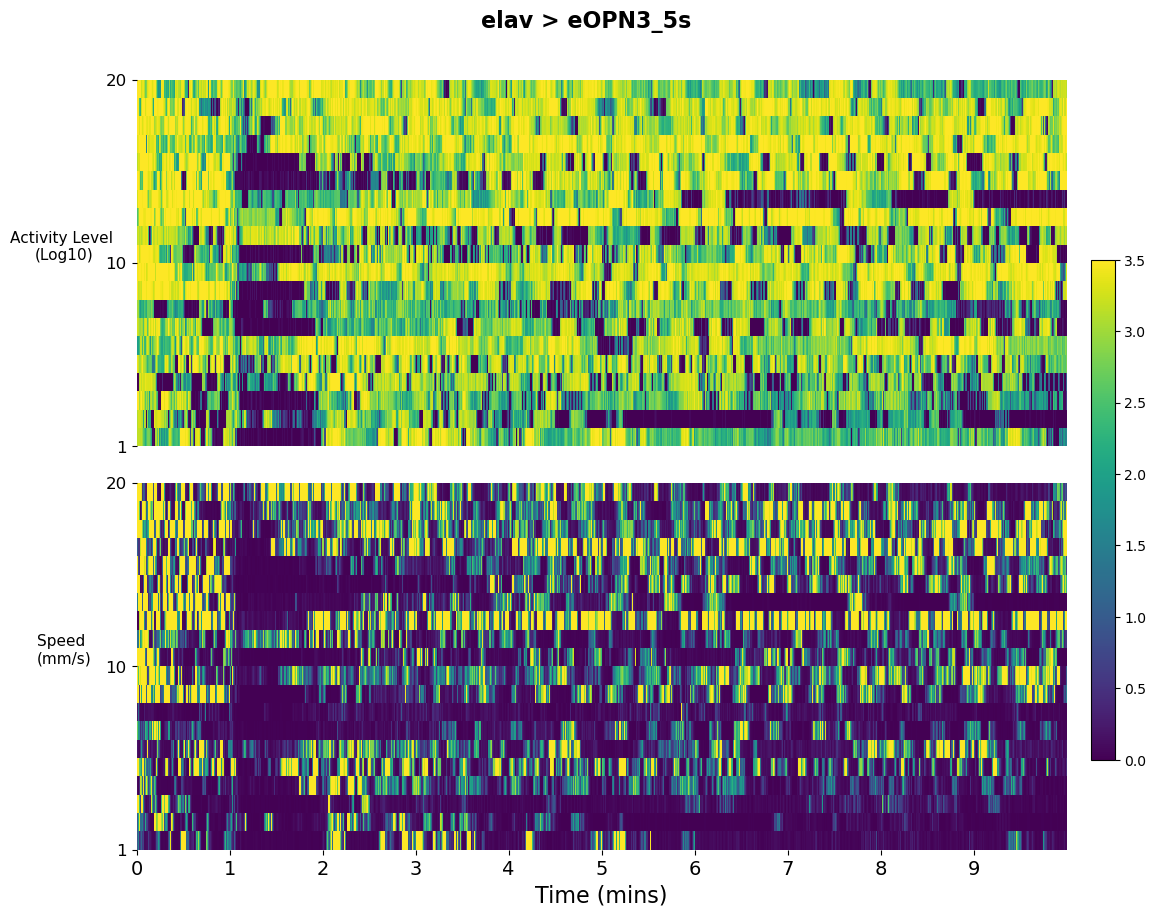

In [71]:
if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"

activitylevel_data = minutegraphs.filter(regex="^ActivityLevel").T.reset_index(drop=True)
speed_data = minutegraphs.filter(regex="^Speed").T.reset_index(drop=True)

num_flies = activitylevel_data.shape[0]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
plt.subplots_adjust(hspace=0.1) 

hm1 = sns.heatmap(activitylevel_data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, vmin=0, vmax=3.5, ax=axes[0])
quadmesh1 = axes[0].collections[0]
quadmesh1.set_rasterized(True)
quadmesh1.set_edgecolor('face')
quadmesh1.set_linewidth(0)

axes[0].set_yticks([0, num_flies//2, num_flies])
ticklabels = [num_flies, (num_flies+1)//2, 1]
axes[0].set_yticklabels(ticklabels, fontsize=12)
axes[0].set_ylabel("Activity Level \n(Log10)", rotation=0, labelpad=30, fontsize=11)
axes[0].tick_params(axis='x', bottom=False)                                                                                                   
axes[0].set_xlabel('')

hm2 = sns.heatmap(speed_data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, vmin=0, vmax=3.5, ax=axes[1])
quadmesh2 = axes[1].collections[0]
quadmesh2.set_rasterized(True)
quadmesh2.set_edgecolor('face')
quadmesh2.set_linewidth(0)
axes[1].set_ylabel("Speed \n(mm/s)", rotation=0, labelpad=30, fontsize=11)
axes[1].set_yticks([0, num_flies])
axes[1].set_yticklabels([1, num_flies], fontsize=12)

tick_times = list(range(0, int(intendedtime/60)+1, 1))  # 0, 1, 2, ... minutes
tick_positions = [list(speed_data.columns).index(float(t)) for t in tick_times if float(t) in speed_data.columns]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_times[:len(tick_positions)], rotation=0, fontsize=14)
axes[1].set_xlabel("Time (mins)", fontsize=16)
axes[1].set_yticks([0, num_flies//2, num_flies])
axes[1].set_yticklabels(ticklabels, fontsize=12)


cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.5])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=3.5))
fig.colorbar(sm, cax=cbar_ax)

fig.suptitle(fileofinterestname.replace("x", ">"), weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')
axes[0].patch.set_facecolor('white')
axes[1].patch.set_facecolor('white')


# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\"
#             + "Combined_heatmap_mins_" + fileofinterestname + "_" +str(illum_duration) + "s.svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)